<a href="https://colab.research.google.com/github/Vansh-Rajderkar5901/OIBSIP/blob/main/VanshRajderkar_Project4Level1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
df = pd.read_csv('/content/user_reviews.csv')

df = df[['Translated_Review','Sentiment']]
df.dropna(inplace=True)

print(df.head())

                                   Translated_Review Sentiment
0  I like eat delicious food. That's I'm cooking ...  Positive
1    This help eating healthy exercise regular basis  Positive
3         Works great especially going grocery store  Positive
4                                       Best idea us  Positive
5                                           Best way  Positive


In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+','',text)

    text = re.sub(r'[^a-zA-Z]',' ',text)

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return ' '.join(words)

df['Cleaned_Review'] = df['Translated_Review'].apply(clean_text)

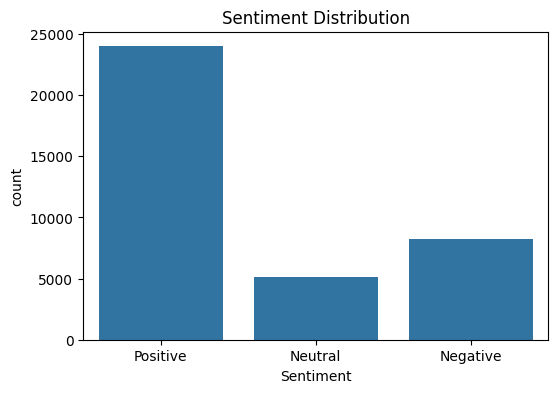

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment',data=df)
plt.title('Sentiment Distribution')
plt.show()

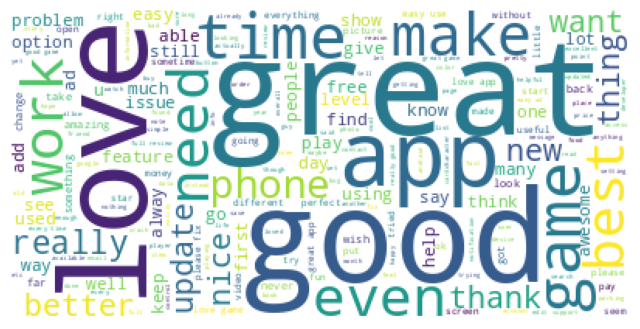

In [7]:
from wordcloud import WordCloud

positive_text = " ".join(df[df['Sentiment']=='Positive']['Cleaned_Review'])

wc = WordCloud(background_color='white').generate(positive_text)

plt.figure(figsize=(8,5))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [8]:
X = df['Cleaned_Review']
y = df['Sentiment']

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(X)

In [9]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [10]:
nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy :",accuracy_score(y_test,pred_nb))

Naive Bayes Accuracy : 0.7353726956986375


In [11]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy :",accuracy_score(y_test,pred_lr))

Logistic Regression Accuracy : 0.9071600320598451


In [12]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy :",accuracy_score(y_test,pred_rf))

Random Forest Accuracy : 0.9079615281859471


In [13]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

    Negative       0.90      0.80      0.85      1653
     Neutral       0.87      0.83      0.85      1049
    Positive       0.92      0.96      0.94      4784

    accuracy                           0.91      7486
   macro avg       0.90      0.86      0.88      7486
weighted avg       0.91      0.91      0.91      7486



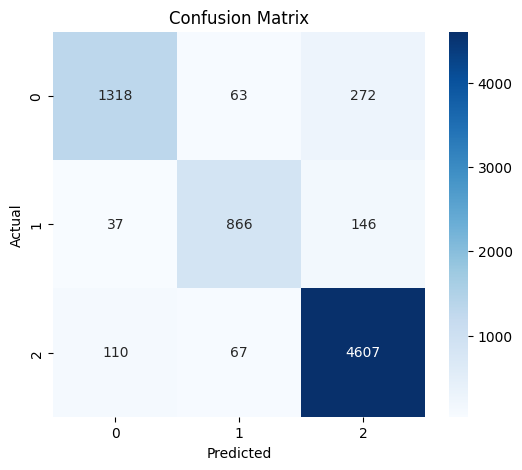

In [14]:
cm = confusion_matrix(y_test,pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [15]:
def predict_sentiment(review):

    review = clean_text(review)

    vector = tfidf.transform([review])

    prediction = lr.predict(vector)

    return prediction[0]


text = input("Enter Review : ")

print("Sentiment :",predict_sentiment(text))

Enter Review : This app is amazing and very easy to use
Sentiment : Positive
